In [1]:
import os
import sys

# Add the parent directory to the system path
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
from numpy.polynomial.chebyshev import Chebyshev
import json
import pprint as pp
from util.filehandler import load_gp_model, load_chebyshev_approximation
from util.gaussian_processes import fast_chebyshev_sample, fast_chebyshev_evaluate
import matplotlib.pyplot as plt

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
shale_model = load_gp_model("../data/models/shale_pl_vp_vs.pth")
depth_min, depth_max = shale_model['depth_range']
shale_dict = fit_chebyshev_approximation(shale_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(shale_dict, "../data/grids/chebyshev/shale_pl_vp_vs.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


NameError: name 'fit_chebyshev_approximation' is not defined

In [ ]:
brine_model = load_gp_model("../data/models/brine_pl_vp_vs.pth")
depth_min, depth_max = brine_model['depth_range']
brine_dict = fit_chebyshev_approximation(brine_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(brine_dict, "../data/grids/chebyshev/brine_pl_vp_vs.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [44]:
oil_model = load_gp_model("../data/models/oil_pl_vp_vs.pth")
depth_min, depth_max = oil_model['depth_range']
oil_dict = fit_chebyshev_approximation(oil_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(oil_dict, "../data/grids/chebyshev/oil_pl_vp_vs.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [46]:
gas_model = load_gp_model("../data/models/gas_pl_vp.pth")
depth_min, depth_max = gas_model['depth_range']
gas_dict = fit_chebyshev_approximation(gas_model,
                                         degree=10,
                                         n_grid_points=int(depth_max-depth_min),
                                         n_samples=50,
                                         log_transform=True)
save_chebyshev_approximation(gas_dict, "../data/grids/chebyshev/gas_pl_vp.json")

/home/spaceswimmer/Documents/nnseismic/synthoseis/.venv/lib/python3.9/site-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.8.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [4]:
import numpy as np
from scipy.optimize import curve_fit


def linear_trend(depth, data):
    """
    Fit a linear trend: a * depth + b
    
    Parameters:
        depth: Array of depth values (can have duplicates)
        data: Array of data values corresponding to each depth
    
    Returns:
        trend: Fitted trend values at input depths
        coefficients: [slope, intercept]
    """
    coefficients = np.polyfit(depth, data, 1)
    trend = np.polyval(coefficients, depth)
    return trend, coefficients


def polynomial_trend(depth, data, degree=3):
    """
    Fit a polynomial trend.
    
    Parameters:
        depth: Array of depth values (can have duplicates)
        data: Array of data values corresponding to each depth
        degree: Polynomial degree (default 3)
    
    Returns:
        trend: Fitted trend values at input depths
        coefficients: Polynomial coefficients (highest degree first)
    """
    coefficients = np.polyfit(depth, data, degree)
    trend = np.polyval(coefficients, depth)
    return trend, coefficients

def exp_func(d, a, b, c):
        return a * np.exp(b * d) + c

def exponential_trend(depth, data):
    """
    Fit an exponential trend: a * exp(b * depth) + c
    
    Parameters:
        depth: Array of depth values (can have duplicates)
        data: Array of data values corresponding to each depth
    
    Returns:
        trend: Fitted trend values at input depths
        parameters: [a, b, c]
    """
    
    initial_guess = [data.std(), 0.001, data.mean()]
    parameters, _ = curve_fit(exp_func, depth, data, p0=initial_guess, maxfev=5000)
    trend = exp_func(depth, *parameters)
    
    return trend, parameters

def power_func(d, a, b, c):
        return a * np.power(d, b) + c

def power_law_trend(depth, data):
    """
    Fit a power law trend: a * depth^b + c
    
    Parameters:
        depth: Array of depth values (can have duplicates)
        data: Array of data values corresponding to each depth
    
    Returns:
        trend: Fitted trend values at input depths
        parameters: [a, b, c]
    """
    
    initial_guess = [1.0, 0.5, data.min()]
    parameters, _ = curve_fit(power_func, depth, data, p0=initial_guess, maxfev=5000)
    trend = power_func(depth, *parameters)
    
    return trend, parameters

In [7]:
cheb_params = load_chebyshev_approximation('../data/grids/chebyshev/oil_pl_vp_vs.json')
# cheb_params['log_transform'] = False
depth_min, depth_max = 1300, 3800
depths = np.arange(depth_min, depth_max, 1)
samples = fast_chebyshev_sample(cheb_params, depths, n_samples=1)
mean, std = fast_chebyshev_evaluate(cheb_params, depths)

poly: param = [-2.11710451e-04  1.67274767e+00 -7.60014222e+02]
[-2.11710451e-04  1.67274767e+00 -7.60014222e+02]


(0.0, 2800.0)

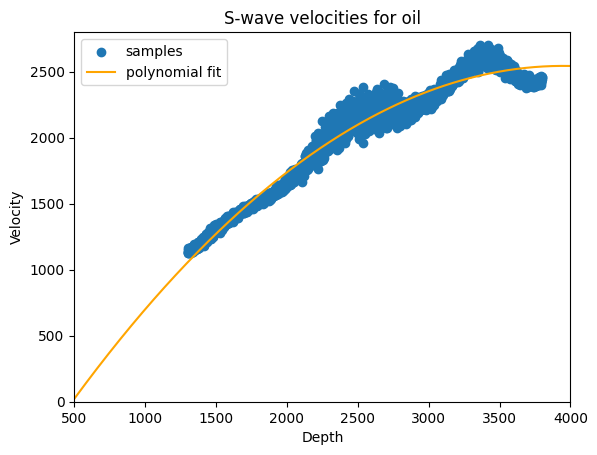

In [16]:
data = samples[:, :, 2].flatten()
ddepths = np.tile(depths, samples.shape[0])
plt.scatter(ddepths, data, label='samples')
edepth = np.arange(0, 4000, 1)

trend, param = polynomial_trend(ddepths, data, degree=2)
# param[2] = np.abs(param[2])
trend = np.polyval(param, edepth)
plt.plot(edepth, trend, label='polynomial fit', color='orange')
print(f'poly: param = {param}')
print(param)

plt.legend()
plt.title('S-wave velocities for oil')
plt.xlabel('Depth')
plt.ylabel('Velocity')
plt.xlim((500, 4000))
plt.ylim((0,2800))
# trend, param = exponential_trend(ddepths, data)
# trend = exp_func(edepth, *param)
# plt.scatter(edepth, trend, label='exp')
# plt.legend()
# print('exp: param = ', param)

# trend, param = power_law_trend(ddepths, data)
# trend = power_func(edepth, *param)
# plt.scatter(edepth, trend, label='power')
# plt.legend()

In [2]:
sys.path.insert(0, os.path.abspath('../synthoseis/'))
from rockphysics.rpm_tagilsk_trends import RPMTagilsk
test = RPMTagilsk('lala')
edepth = np.arange(0, 4000, 1)
brine = test.calc_brine_sand_properties(edepth, edepth, edepth)
oil = test.calc_oil_sand_properties(edepth, edepth, edepth)
gas = test.calc_gas_sand_properties(edepth, edepth, edepth)
shale = test.calc_shale_properties(edepth, edepth, edepth)

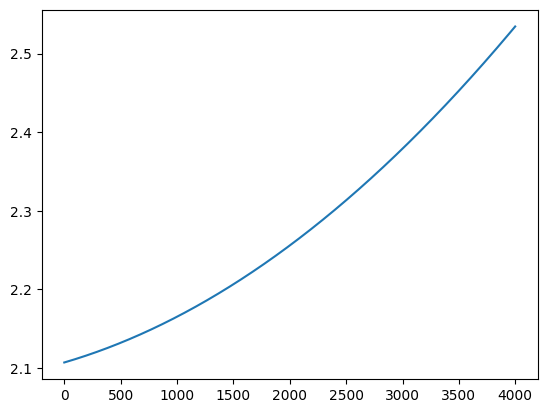

In [9]:
plt.plot(edepth, brine.rho)